## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input

import gradio as gr

import warnings 
warnings.filterwarnings('ignore')

print("Required Libraries Imported")

C:\anaconda\envs\ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Required Libraries Imported


## Load Dataset

In [2]:
df = pd.read_csv(r"Psychological Manipulation Detection Dataset.csv")
df.head()

,conversation_id,manipulation_type,is_manipulation,context_type,conversation_length,manipulation_intensity,messages,question_count,Unnamed: 8
0,conv_00000,guilt_tripping,True,friend,3,0.705,"[{""speaker"": ""A"", ""text"": ""Remember when I hel...",1,NaN
1,conv_00001,charm_flattery,True,friend,6,0.530,"[{""speaker"": ""A"", ""text"": ""I don't tell just a...",2,NaN
2,conv_00002,direct_coercion,True,family,7,0.651,"[{""speaker"": ""A"", ""text"": ""Just do it"", ""senti...",1,NaN
3,conv_00003,gaslighting,True,friend,6,0.673,"[{""speaker"": ""A"", ""text"": ""You're being way to...",0,NaN
4,conv_00004,guilt_tripping,True,friend,4,0.331,"[{""speaker"": ""A"", ""text"": ""Go ahead. Have fun....",1,NaN


In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns)


Shape: (10000, 9)
Columns: Index(['conversation_id', 'manipulation_type', 'is_manipulation',
       'context_type', 'conversation_length', 'manipulation_intensity',
       'messages', 'question_count', 'Unnamed: 8'],
      dtype='object')


## Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   conversation_id         10000 non-null  object 
 1   manipulation_type       10000 non-null  object 
 2   is_manipulation         10000 non-null  bool   
 3   context_type            10000 non-null  object 
 4   conversation_length     10000 non-null  int64  
 5   manipulation_intensity  10000 non-null  float64
 6   messages                10000 non-null  object 
 7   question_count          10000 non-null  int64  
 8   Unnamed: 8              0 non-null      float64
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 634.9+ KB


In [5]:
df.describe()

,conversation_length,manipulation_intensity,question_count,Unnamed: 8
count,10000.000000,10000.000000,10000.00000,0.0
mean,5.502300,0.517148,1.04590,NaN
std,1.709177,0.294557,0.96555,NaN
min,3.000000,0.000000,0.00000,NaN
25%,4.000000,0.335000,0.00000,NaN
50%,6.000000,0.561000,1.00000,NaN
75%,7.000000,0.747000,2.00000,NaN
max,8.000000,1.000000,5.00000,NaN


## Distribution Plots

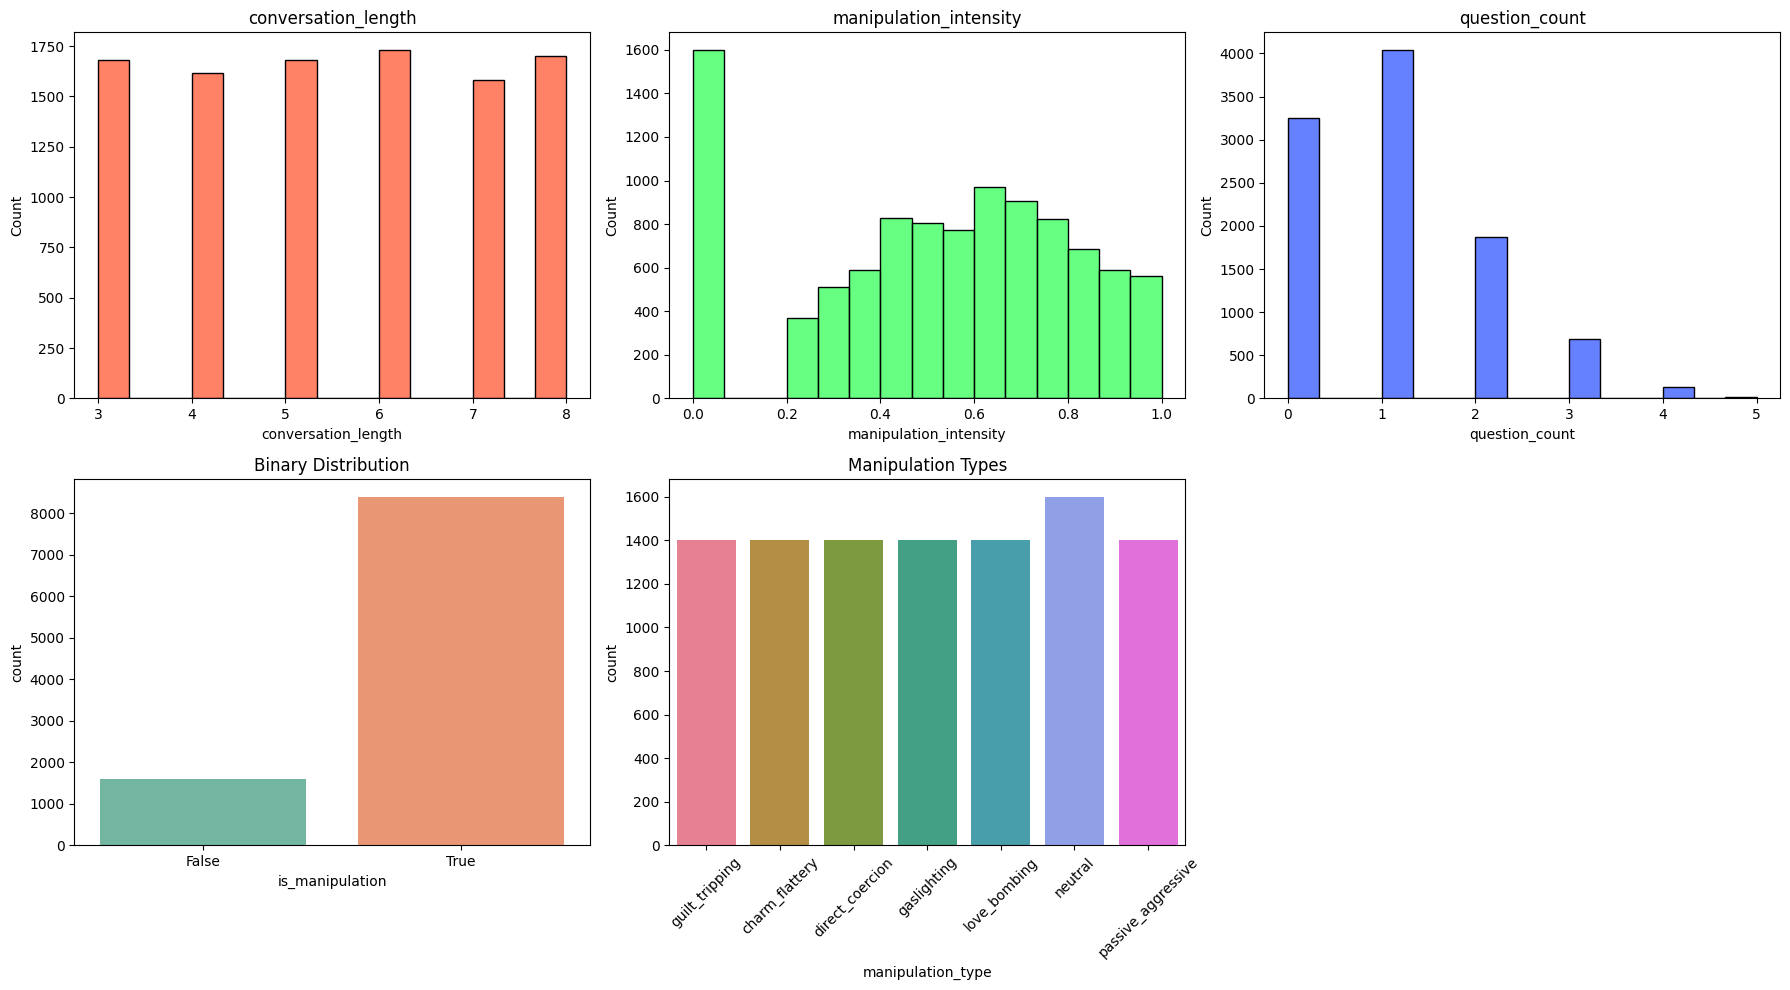

In [6]:
num_cols = ['conversation_length', 'manipulation_intensity', 'question_count']

plt.figure(figsize=(18,10))

colors = ['#FF5733', '#33FF57', '#3357FF']

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], bins=15, color=colors[i-1], edgecolor='black')
    plt.title(col)

plt.subplot(2,3,4)
sns.countplot(x='is_manipulation', data=df, palette='Set2')
plt.title("Binary Distribution")

plt.subplot(2,3,5)
sns.countplot(x='manipulation_type', data=df, palette='husl')
plt.xticks(rotation=45)
plt.title("Manipulation Types")

plt.tight_layout()
plt.show()


## Data Transformation

In [7]:
le_type = LabelEncoder()
df['manipulation_type_encoded'] = le_type.fit_transform(df['manipulation_type'])

X = df['messages']
y_bin = df['is_manipulation']
y_type = df['manipulation_type_encoded']


## Train - Test Split

In [8]:
X_train, X_test, y_bin_train, y_bin_test, y_type_train, y_type_test = train_test_split(
    X, y_bin, y_type,
    test_size=0.2,
    stratify=y_bin,
    random_state=42
)

In [9]:
# Reset index
X_train = X_train.reset_index(drop=True)
y_bin_train = y_bin_train.reset_index(drop=True)
y_type_train = y_type_train.reset_index(drop=True)


## Tokenization

In [10]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


## Handle Imbalance

In [11]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_bin_train),
    y=y_bin_train
)

class_weights_dict = dict(enumerate(class_weights))

## Model Building (LSTM)

In [12]:
input_layer = Input(shape=(max_len,))
embedding = Embedding(input_dim=5000, output_dim=64)(input_layer)
lstm = LSTM(64)(embedding)

# Outputs
output_bin = Dense(1, activation='sigmoid', name='binary_output')(lstm)
output_type = Dense(len(le_type.classes_), activation='softmax', name='type_output')(lstm)

model = Model(inputs=input_layer, outputs=[output_bin, output_type])


## Compiling

In [13]:
model.compile(
    optimizer='adam',
    loss=['binary_crossentropy', 'sparse_categorical_crossentropy'],
    metrics=['accuracy', 'accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 100, 64)           │         320,000 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 64)                │          33,024 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ binary_output (Dense)         │ (None, 1)                 │              65 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ type_output (Dense)           │ (None, 7)                 │             455 │ lstm[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 353,544 (1.35 MB)

 Trainable params: 353,544 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [14]:
model.fit(
    X_train_pad,
    [np.array(y_bin_train), np.array(y_type_train)],
    epochs=3,
    batch_size=32,
    validation_split=0.2)

Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - binary_output_accuracy: 0.9361 - binary_output_loss: 0.2020 - loss: 1.9252 - type_output_accuracy: 0.2541 - type_output_loss: 1.7232 - val_binary_output_accuracy: 0.9987 - val_binary_output_loss: 0.0144 - val_loss: 1.5232 - val_type_output_accuracy: 0.3031 - val_type_output_loss: 1.5088
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - binary_output_accuracy: 0.9980 - binary_output_loss: 0.0146 - loss: 1.4504 - type_output_accuracy: 0.4231 - type_output_loss: 1.4358 - val_binary_output_accuracy: 0.9962 - val_binary_output_loss: 0.0268 - val_loss: 1.1365 - val_type_output_accuracy: 0.5781 - val_type_output_loss: 1.1097
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - binary_output_accuracy: 0.9944 - binary_output_loss: 0.0264 - loss: 0.6760 - type_output_accuracy: 0.8148 - type_output_loss: 0.6496 - val_binary_output_accuracy: 0.9975 - val_binary_output_loss: 0.0142 - val_loss: 0.4192 - val_type_output_accuracy: 0.8931 - va

## Prediction

In [15]:
def predict(text):
    try:
        seq = tokenizer.texts_to_sequences([text])
        pad = pad_sequences(seq, maxlen=max_len)

        pred_bin, pred_type = model.predict(pad)

        prob = float(pred_bin[0][0])
        if prob > 0.5:
            bin_result = f"⚠ MANIPULATION DETECTED — {round(prob*100,2)}%"
        else:
            bin_result = f"✔ NOT MANIPULATION — {round((1-prob)*100,2)}%"

        pred_index = int(np.argmax(pred_type, axis=1)[0])
        label = le_type.classes_[pred_index]
        type_result = label if prob > 0.5 else "None"

        return bin_result, type_result

    except Exception as e:
        return f"ERROR: {str(e)}", "Error"

## Gradio UI

In [16]:
css = """
/* Page background */
body, .gradio-container {
    background-color: #0a0a0a !important;
    color: #ff2222 !important;
    font-family: 'Courier New', monospace !important;
}

/* Title */
h1 {
    color: #ff0000 !important;
    text-align: center !important;
    font-size: 2em !important;
    letter-spacing: 4px !important;
    text-transform: uppercase !important;
    border-bottom: 1px solid #ff0000 !important;
    padding-bottom: 10px !important;
}

/* Description */
.gr-prose p {
    color: #cc0000 !important;
    text-align: center !important;
    font-style: italic !important;
    letter-spacing: 1px !important;
}

/* Input/Output boxes */
label {
    color: #ff3333 !important;
    letter-spacing: 2px !important;
    font-size: 0.85em !important;
    text-transform: uppercase !important;
}

textarea, input[type="text"] {
    background-color: #1a0000 !important;
    color: #ff4444 !important;
    border: 1px solid #880000 !important;
    border-radius: 4px !important;
    font-family: 'Courier New', monospace !important;
    caret-color: #ff0000 !important;
}

textarea::placeholder {
    color: #550000 !important;
}

textarea:focus {
    border-color: #ff0000 !important;
    outline: none !important;
    box-shadow: 0 0 8px rgba(255, 0, 0, 0.4) !important;
}

/* Submit button */
.gr-button-primary, button[variant="primary"] {
    background-color: #880000 !important;
    color: #ffffff !important;
    border: 1px solid #ff0000 !important;
    border-radius: 4px !important;
    font-family: 'Courier New', monospace !important;
    letter-spacing: 3px !important;
    text-transform: uppercase !important;
    font-weight: bold !important;
    transition: background-color 0.2s !important;
}

.gr-button-primary:hover, button[variant="primary"]:hover {
    background-color: #cc0000 !important;
}

/* Clear/secondary buttons */
button[variant="secondary"] {
    background-color: #1a0000 !important;
    color: #cc0000 !important;
    border: 1px solid #550000 !important;
    font-family: 'Courier New', monospace !important;
}

/* Output result boxes */
.gr-textbox input, .output-textbox textarea {
    background-color: #120000 !important;
    color: #ff6666 !important;
    border: 1px solid #660000 !important;
    font-family: 'Courier New', monospace !important;
}

/* Block panels */
.gr-panel, .gr-box {
    background-color: #0f0000 !important;
    border: 1px solid #330000 !important;
}
"""

In [17]:
iface = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter conversation text for psychological analysis...",
        label="[ INPUT — SUBJECT STATEMENT ]"
    ),
    outputs=[
        gr.Textbox(label="[ ANALYSIS RESULT ]"),
        gr.Textbox(label="[ MANIPULATION CLASS ]")
    ],
    title="PSYCHOLOGICAL MANIPULATION DETECTOR",
    description="*Analyze conversations for psychological manipulation patterns using deep learning*",
    css=css,
    theme=gr.themes.Base()
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://25133cd7eece717109.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━